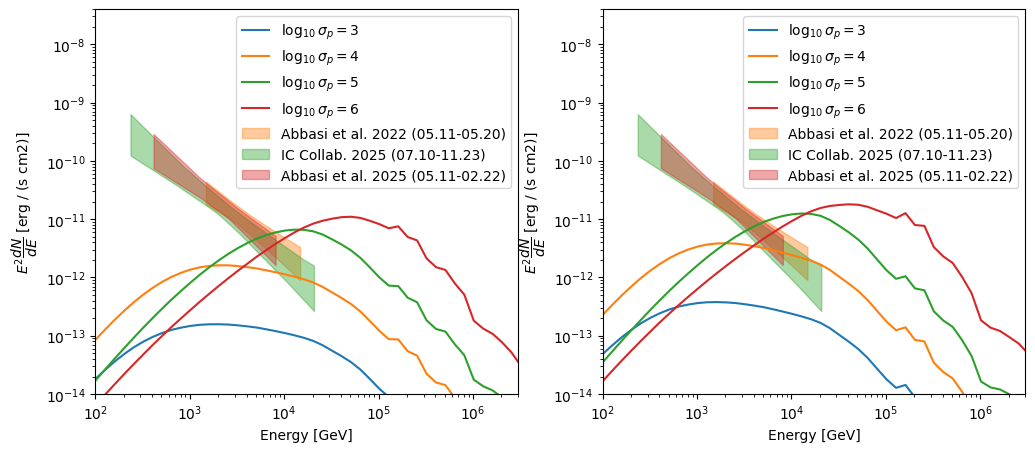

In [4]:
import numpy as np
import astropy.constants as const
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
from Coronal_neutrinos_class import coronal_nu
from astropy.cosmology import FlatLambdaCDM
import pandas as pd


def R_eff_value(M_bh, R_bar=12, beta=0.1):
    rg = (const.G * M_bh*u.M_sun / const.c**2).to(u.cm)
    R = (3*beta/(4*np.pi))**(1/3) * (R_bar*rg)
    # print(f"{R:.2e}")
    return R

def lum_2_flux(cosmo, lum, dist=None, redshift=None):
    if redshift is not None:
        dl = cosmo.luminosity_distance(redshift)
    elif dist is not None:
        dl = dist*u.pc
    else:
        raise Exception("Either redshift or dist in pc, my firend")
    flux = (lum*u.erg/u.s) / (4*np.pi*dl**2)
    return (flux.to(u.erg/u.s/u.cm**2)).value

def coronal_neutrino(xray_lum_2_10, M_bh, redshift, sigma_p, H0=69.32, Om0=0.29, x_rays_params=None):
    # Checking the input
    if xray_lum_2_10 > 100:
        raise ValueError("Pass the log10 of the X-ray luminoisty.")
    else:
        xray_lum_2_10 = np.clip(xray_lum_2_10, 42, 47)
        if xray_lum_2_10 == 42 or xray_lum_2_10==47:
            warnings.warn(f"Warning: xray_lum_2_10 is outside [42, 47]. Using boundary value {xray_lum_2_10} as the model does not extrapolate.")
    if not isinstance(sigma_p, int) or sigma_p < 3 or sigma_p > 6:
        raise ValueError("sigma_p must be an integer strictly between 3 and 6")
    
    R_eff=np.log10(R_eff_value(M_bh).value)
    R_eff_clip=np.clip(R_eff, 12.4, 14.4)
    if R_eff_clip == 12.4 or R_eff_clip==14.4:
        print(f"{np.log10(R_eff_value(M_bh).value)}")
        warnings.warn(f"Warning: R_eff is outside [12.4, 14.4]. Using boundary value {R_eff_clip} as the model does not extrapolate.")

    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    model=coronal_nu(sigma_p=sigma_p, L_X=xray_lum_2_10, R=R_eff, x_ray_parms=x_rays_params)
    energy = (model.energ_range*u.eV).to(u.GeV) # Output in ev, passing to GeV
    lum = 10**model.neutrino_spectrum()
    sed = (lum_2_flux(cosmo=cosmo, lum=lum, redshift=redshift)*u.erg/u.s/u.cm**2).to(u.GeV/u.s/u.cm**2) # Output in erg/s/cm2, passing to GeV/s/cm2
    flux = (sed / energy**2).to(1/u.GeV/u.s/u.cm**2) # The detector works with neutrino fluxes.
    flux /= 3 # This model gives back the total neutrino luminosity. I divide by 3 to account for track-like events
    del model, lum
    return energy, flux

def plot_ngc_IC(df, label, const=1, x_axis="GeV", y_axis="TeV", color="C0", ax=None):
    if ax is None:
        ax = plt.gca()
    
    logE_high = df["flux_high_X"].to_numpy()    # The original values are in GeV
    logF_high = df["flux_high_Y"].to_numpy()    # The original values are in TeV/s/cm2

    logE_low = df["flux_low_X"].to_numpy()      # The original values are in GeV
    logF_low = df["flux_low_Y"].to_numpy()      # The original values are in TeV/s/cm2

    # Common log-energy grid
    emin = max(logE_low.min(), logE_high.min())
    emax = min(logE_low.max(), logE_high.max())
    logE_common = np.linspace(emin, emax, 300)

    # Interpolate
    logF_high_i = np.interp(logE_common, logE_high, logF_high)
    logF_low_i  = np.interp(logE_common, logE_low,  logF_low)

    # Convert to physical units
    energy = (10**logE_common * u.GeV)
    if x_axis == "TeV":
        energy = energy.to(u.TeV)
    if y_axis == "TeV":
        flux_high = 10**logF_high_i * u.TeV / u.s / u.cm**2
        flux_low  = 10**logF_low_i  * u.TeV / u.s / u.cm**2
    elif y_axis == "GeV":
        flux_high = (10**logF_high_i * u.TeV / u.s / u.cm**2).to(u.GeV / u.s / u.cm**2)
        flux_low  = (10**logF_low_i  * u.TeV / u.s / u.cm**2).to(u.GeV / u.s / u.cm**2)
    elif y_axis == "erg":
        flux_high = (10**logF_high_i * u.TeV / u.s / u.cm**2).to(u.erg / u.s / u.cm**2)
        flux_low  = (10**logF_low_i  * u.TeV / u.s / u.cm**2).to(u.erg / u.s / u.cm**2)

    ax.fill_between(
        energy.value,
        np.minimum(flux_low.value, flux_high.value)*const,
        np.maximum(flux_low.value, flux_high.value)*const,
        alpha=0.4,
        label=label,
        color=color,
    )
    return

LX=42.93
M_bh=6700000 # Solar masses
R_eff=np.log10(R_eff_value(M_bh).value)
redshift=0.00348372

# So lets assume for the plot on the right spectral index of 2 from 0.1 - 100 keV.
# For the plot on the right same measured luminosity but gamma = 1.9 from 0.1 - 150 keV.
# From Ricci et al. 2017, the used a cutoffpwl with index 1.9 and a E_cut >= 145, so yeaah
x_ray_params = {
    'e1_in': 2.,
    'e2_in': 10,
    'gamma_in': 2,
    'e1_out': 0.1,
    'e2_out': 100,
    'gamma_out': 1.7
}
fig, ax = plt.subplots(1,2, figsize=(12,5))

for sigma_p in range(3,7,1):
    energy, flux = coronal_neutrino(xray_lum_2_10=LX, M_bh=M_bh, redshift=redshift, sigma_p=sigma_p)
    y = (flux*energy**2).to(u.erg/u.s/u.cm**2)
    ax[0].loglog(energy, y, 
    # label=f'$\\log_{{10}} \\sigma_p={sigma_p}$\n$\\log_{{10}} L_X={round(LX)}$\n$\\log_{{10}}R={R_eff:.1f}$'
    label=f'$\\log_{{10}} \\sigma_p={sigma_p}$'
    )
    energy, flux = coronal_neutrino(xray_lum_2_10=LX, M_bh=M_bh, redshift=redshift, sigma_p=sigma_p, x_rays_params=x_ray_params)
    y = (flux*energy**2).to(u.erg/u.s/u.cm**2)
    ax[1].loglog(energy, y, 
    # label=f'$\\log_{{10}} \\sigma_p={sigma_p}$\n$\\log_{{10}} L_X={round(LX)}$\n$\\log_{{10}}R={R_eff:.1f}$'
    label=f'$\\log_{{10}} \\sigma_p={sigma_p}$'
    )

for a in ax:
    df = pd.read_csv(f"../ngc_IC/science_2022.csv") # only muon
    label = "Abbasi et al. 2022 (05.11-05.20)"
    plot_ngc_IC(df, label, const=1, x_axis="GeV", y_axis="TeV", color="C1", ax=a)
    df = pd.read_csv(f"../ngc_IC/evidence_bright_sy_IC_2025_all_flavor.csv")
    label = "IC Collab. 2025 (07.10-11.23)"
    plot_ngc_IC(df, label, const=1/3, x_axis="GeV", y_axis="TeV", color="C2", ax=a)
    df = pd.read_csv(f"../ngc_IC/search_bright_sy_IC_2025_only_mu.csv")
    label = "Abbasi et al. 2025 (05.11-02.22)"
    plot_ngc_IC(df, label, const=1, x_axis="GeV", y_axis="TeV", color="C3", ax=a)
    a.set_xlabel(f'Energy [{energy.unit}]')
    a.set_ylabel(fr'$E^2\dfrac{{dN}}{{dE}}$ [{y.unit}]')
    a.set_ylim([1e-14, 4e-8])
    a.set_xlim([1e2, 3e6])
    a.legend()
plt.show()